In [1]:
import numpy as np
import pandas as pd
import utils
import pickle

from matplotlib import pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

In [2]:
with open(f'data/dataset_clean.pkl', 'rb') as file:
    X_train, X_val, X_test, y_train, y_val, y_test = pickle.load(file)['retval']

In [3]:
quantiles = [0.05, 0.16, 0.5, 0.84, 0.95]
models = {}
preds = {}
for q in quantiles:
    gbr_q = HistGradientBoostingRegressor(loss='quantile', quantile=q, learning_rate=0.1, max_depth=20, max_iter=200, random_state=42)
    gbr_q.fit(X_train, y_train)
    models[q] = gbr_q
    preds[q] = gbr_q.predict(X_val)

# Stack the 5 quantile predictions into one array per galaxy
# Columns ordered to match `quantiles`: [0.05, 0.16, 0.5, 0.84, 0.95]
preds_matrix = np.column_stack([preds[q] for q in quantiles])

In [4]:
# ----------
# Check for quantile crossings
# ----------

# Stack the 5 quantile predictions into one array per galaxy
preds_matrix = np.column_stack([preds[q] for q in quantiles])

# For each galaxy (row), check that predictions increase or stay the same across quantiles
# q=0.05 <= q=0.16 <= q=0.5 <= q=0.84 <= q=0.95
quantile_crossing = np.all(np.diff(preds_matrix, axis=1) >= 0, axis=1)

# The number and percent of crossings
n_crossed = (~quantile_crossing).sum()
pct_crossed = n_crossed / len(quantile_crossing) * 100

print(f"Galaxies with quantile crossing: {n_crossed}/{len(quantile_crossing)} ({pct_crossed:.2f}%)")

Galaxies with quantile crossing: 182/99063 (0.18%)


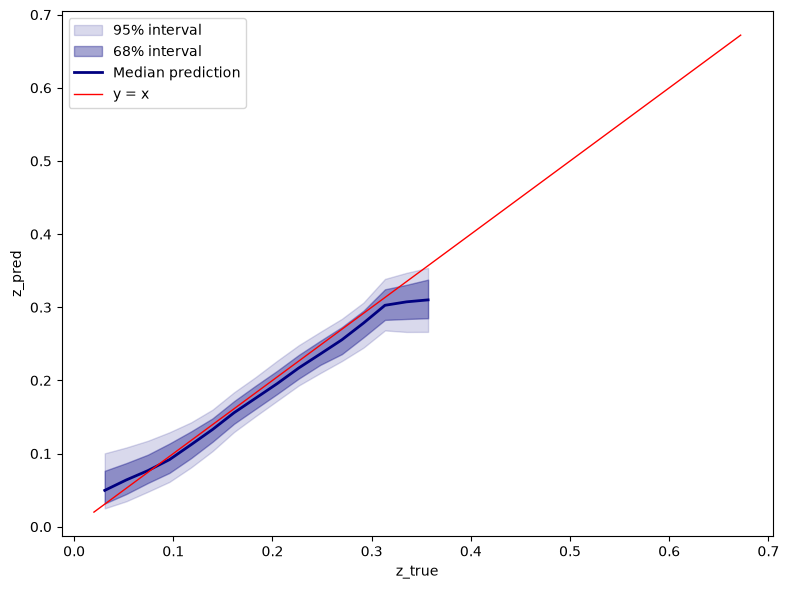

In [5]:
# Bin by z_true, compute median prediction + interval bounds within each bin
z_true = y_val
n_bins = 30
bin_edges = np.linspace(z_true.min(), z_true.max(), n_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

median_line = np.full(n_bins, np.nan)
q16_line = np.full(n_bins, np.nan)
q84_line = np.full(n_bins, np.nan)
q05_line = np.full(n_bins, np.nan)
q95_line = np.full(n_bins, np.nan)

for i in range(n_bins):
    mask = (z_true >= bin_edges[i]) & (z_true < bin_edges[i + 1])
    if mask.sum() < 10:  # skip sparse bins
        continue
    median_line[i] = np.median(preds_matrix[mask, 2])   # column 2 = q=0.5
    q16_line[i] = np.median(preds_matrix[mask, 1])       # column 1 = q=0.16
    q84_line[i] = np.median(preds_matrix[mask, 3])       # column 3 = q=0.84
    q05_line[i] = np.median(preds_matrix[mask, 0])       # column 0 = q=0.05
    q95_line[i] = np.median(preds_matrix[mask, 4])       # column 4 = q=0.95

# Plot z_true vs. median predictions (add shaded regions for intervals)
fig, ax = plt.subplots(figsize=(8, 6))

# 95% interval
ax.fill_between(bin_centers, q05_line, q95_line, color='navy', alpha=0.15, label='95% interval')

# 68% interval
ax.fill_between(bin_centers, q16_line, q84_line, color='navy', alpha=0.35, label='68% interval')

# median line
ax.plot(bin_centers, median_line, color='navy', linewidth=2, label='Median prediction')

# y = x reference
ax.plot([z_true.min(), z_true.max()], [z_true.min(), z_true.max()], 'r-', linewidth=1, label='y = x')

ax.set_xlabel('z_true')
ax.set_ylabel('z_pred')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
q50_preds = preds[0.5]

# Calculate and print the metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
print(f"Outlier Fraction: {utils.outlier_fraction(q50_preds, y_val):.16f}")
print(f"Bias:             {utils.bias(q50_preds, y_val):.16f}")
print(f"NMAD:             {utils.nmad(q50_preds, y_val):.16f}")
print("-" * 36)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0266497077617274
Bias:             -0.0009183497334783
NMAD:             0.0159354307958292
------------------------------------


In [7]:
empirical_coverage_68 = np.mean((y_val >= preds[0.16]) & (y_val <= preds[0.84]))
empirical_coverage_90 = np.mean((y_val >= preds[0.05]) & (y_val <= preds[0.95]))

print(empirical_coverage_68)
print(empirical_coverage_90)

0.6748029032030122
0.8930377638472488


In [8]:
# Building the empirical coverages for confidence levels from 0.1 to 0.9
confidence_levels = np.arange(0.1, 1.0, 0.1)
empirical_coverages = []

for conf in confidence_levels:
    lower_q = (1 - conf) / 2
    upper_q = 1 - lower_q

    # Train two models; one for lower quartile (lower_q), one for upper quartile (upper_q)
    gbr_lower_q = HistGradientBoostingRegressor(loss='quantile', quantile=lower_q, learning_rate=0.1, max_depth=20, max_iter=200, random_state=42)
    gbr_upper_q = HistGradientBoostingRegressor(loss='quantile', quantile=upper_q, learning_rate=0.1, max_depth=20, max_iter=200, random_state=42)

    # Train them
    gbr_lower_q.fit(X_train, y_train)
    gbr_upper_q.fit(X_train, y_train)

    # Model prediction
    lower_q_pred = gbr_lower_q.predict(X_val)
    upper_q_pred = gbr_upper_q.predict(X_val)

    # Add to array
    empirical_coverages.append(np.mean((y_val >= lower_q_pred) & (y_val <= upper_q_pred)))

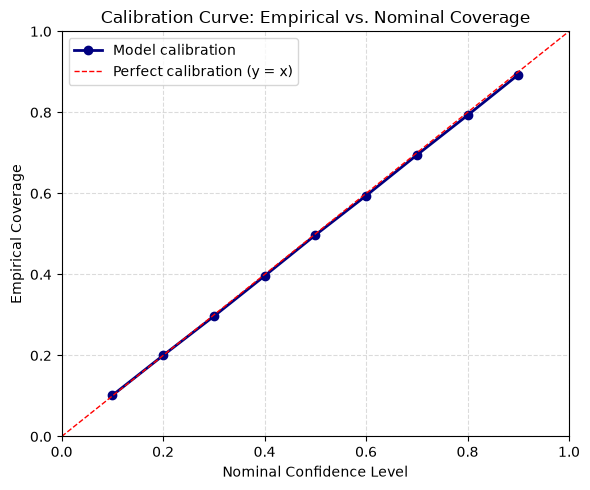

In [9]:
# Create calibration curve for Empirical vs. Nominal Coverage
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(confidence_levels, empirical_coverages, marker='o', color='navy',
        linewidth=2, label='Model calibration')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Perfect calibration (y = x)')

ax.set_xlabel('Nominal Confidence Level')
ax.set_ylabel('Empirical Coverage')
ax.set_title('Calibration Curve: Empirical vs. Nominal Coverage')
ax.legend()
ax.grid(True, linestyle='--', color='lightgray', alpha=0.8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

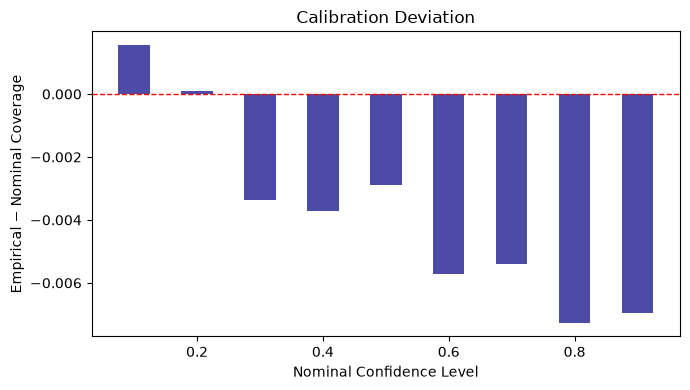

In [10]:
# Residual plot showing the deviation between empirical and nominal coverage
fig, ax = plt.subplots(figsize=(7, 4))
residuals = empirical_coverages - confidence_levels
ax.bar(confidence_levels, residuals, width=0.05, color='navy', alpha=0.7)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Nominal Confidence Level')
ax.set_ylabel('Empirical − Nominal Coverage')
ax.set_title('Calibration Deviation')
plt.tight_layout()
plt.show()

In [11]:
# Get i-band magnitude from the full cleaned dataset using X_val index
with open('data/full_dataset_clean.pkl', 'rb') as file:
    df_full = pickle.load(file)

i_mag_val = df_full.loc[X_val.index, 'modelMag_i']

In [12]:
# Width of 68% interval per galaxy
interval_width_68 = preds[0.84] - preds[0.16]

print("Mean 68% interval width:", interval_width_68.mean())
print("Min/Max:", interval_width_68.min(), interval_width_68.max())

Mean 68% interval width: 0.03960397283234764
Min/Max: 0.005196425339968839 0.2944139342127756


In [13]:
# Checking for degenerate regions in X_val
degenerate_mask = (
    (X_val['g-r'] > 0.4) & (X_val['g-r'] < 0.75) &
    (X_val['r-i'] > 0.15) & (X_val['r-i'] < 0.35)
)

print("-" * 4, "68% Interval Width: Degenerate Region vs. Rest", "-" * 4)
print(f"Degenerate region (N={degenerate_mask.sum()}):  Mean width = {interval_width_68[degenerate_mask].mean():.6f}")
print(f"Rest of sample (N={(~degenerate_mask).sum()}):  Mean width = {interval_width_68[~degenerate_mask].mean():.6f}")

---- 68% Interval Width: Degenerate Region vs. Rest ----
Degenerate region (N=12000):  Mean width = 0.047193
Rest of sample (N=87063):  Mean width = 0.038558


bin            N         Mean 68% Width      
0.02-0.05      12131     0.042054            
0.05-0.08      20352     0.041126            
0.08-0.10      14466     0.041098            
0.10-0.15      30557     0.038916            
0.15-0.20      15183     0.036073            
0.20-0.25      4811      0.036299            
0.25-0.30      1285      0.042061            


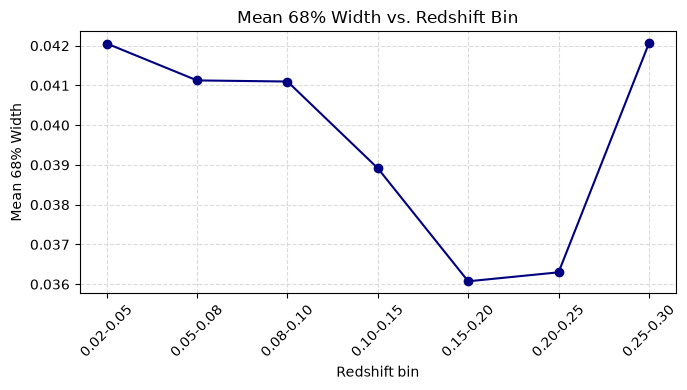

------------------------------------------------------------------------------------------
bin            N         Mean 68% Width      
11.51-15.94      14860     0.040029            
15.94-16.45      14859     0.037952            
16.45-16.75      14859     0.038072            
16.75-16.96      14860     0.038453            
16.96-17.14      14859     0.039301            
17.14-17.32      14859     0.040311            
17.32-22.33      9906      0.044859            


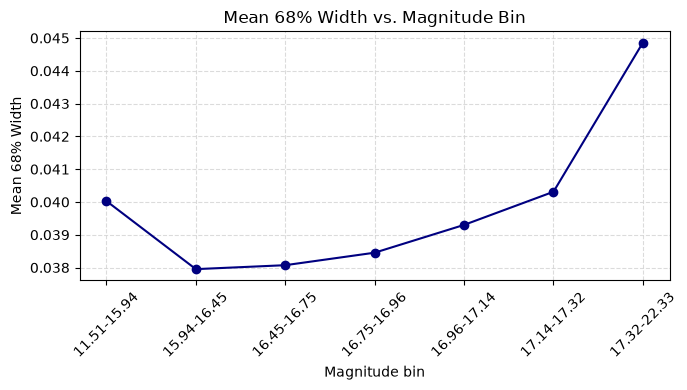

In [14]:
# Custom function to print and plot redshift and magnitude bins vs. the mean 68% interval width
def plot_feature_vs_bin(y_pred, y_val, bin_edges, bin_label, title):
    bin_labels = []
    width = []
    print(f"{'bin':<15}{'N':<10}{'Mean 68% Width':<20}")
    for i in range(len(bin_edges) - 1):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (y_val >= lo) & (y_val < hi)
        if mask.sum() == 0:
            continue
        bin_labels.append(f"{lo:.2f}-{hi:.2f}")
        width.append(y_pred[mask].mean())
        print(f"{lo:.2f}-{hi:.2f}      {mask.sum():<10}{y_pred[mask].mean():<20.6f}")
    
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(bin_labels, width, marker='o', color='navy')
    ax.grid(True, linestyle='--', color='lightgray', alpha=0.8)
    ax.set_xlabel(f'{bin_label} bin')
    ax.set_ylabel('Mean 68% Width')
    plt.xticks(rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Redshift and magnitude bins
z_bins = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
mag_bins = np.percentile(i_mag_val, [0, 15, 30, 45, 60, 75, 90, 100])

# Plotting
plot_feature_vs_bin(interval_width_68, y_val, z_bins, "Redshift", "Mean 68% Width vs. Redshift Bin")
print("-" * 90)
plot_feature_vs_bin(interval_width_68, i_mag_val, mag_bins, "Magnitude", "Mean 68% Width vs. Magnitude Bin")